# Pit Stop Analysis

### Modelling Question
The goal of this project is to predict whether a formula 1 driver finish in top3 or not in a race

### Response variable
The response variable is top3_finish, where\
1 - driver finished in the top 3.\
0 - driver did not finish in the top 3.

### Predictor variables
race_year - Year the race held
race_circuit - circuit where the race take place
race_country - Country of the race
race_altitude_m - Altitude of the circuit
team - team of the driver
race_start_position - Grid position at race start
qualifying_position - Position achieved during qualifying
quali_lap_time_s - Lap time during qualifying
driver_pit_stops_count - Number of pit stops for the driver
driver_pit_stops_avg_duration_s - Average duration of driver's pit stops
race_pit_stops_count - Total pit stops in the race
race_pit_stops_avg_duration_s - Average pit stop duration in the race
race_pit_stops_min_duration_s - Minimum pit stop duration
race_avg_laps_before_pit_stop - Average laps before pit stops

### Dataset
Source: All datasets come from Kaggle: “Formula 1 Race Data” by jtrotman. https://www.kaggle.com/datasets/jtrotman/formula-1-race-data?resource=download&select=lap_times.csv

They contain historical Formula 1 data from 1950 onwards, including race results, circuits, drivers, constructors, lap times, pit stops, qualifying, sprint results, and season standings.

In [24]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
# load the dataset
f1_data = pd.read_csv("f1_driver_classification_data.csv")

In [3]:
f1_data.head()

,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,points,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1,1,85.296,58,25.0,2,23.319500,45,24.342822,37.856,16.867,23.822222,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2,2,85.384,58,18.0,2,23.213000,45,24.342822,37.856,16.867,23.822222,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6,6,85.543,58,15.0,2,25.109000,45,24.342822,37.856,16.867,23.822222,1
3,2011,Albert Park Grand Prix Circuit,Australia,10,Ferrari,5,5,85.707,58,12.0,3,24.055000,45,24.342822,37.856,16.867,23.822222,0
4,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,3,3,85.900,58,10.0,3,24.058667,45,24.342822,37.856,16.867,23.822222,0


In [5]:
f1_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6044 entries, 0 to 6043
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   race_year                        6044 non-null   int64  
 1   race_circuit                     6044 non-null   object 
 2   race_country                     6044 non-null   object 
 3   race_altitude_m                  6044 non-null   int64  
 4   team                             6044 non-null   object 
 5   race_start_position              6044 non-null   int64  
 6   qualifying_position              6044 non-null   int64  
 7   quali_lap_time_s                 6044 non-null   float64
 8   laps_completed                   6044 non-null   int64  
 9   points                           6044 non-null   float64
 10  driver_pit_stops_count           6044 non-null   int64  
 11  driver_pit_stops_avg_duration_s  6044 non-null   float64
 12  race_pit_stops_count

In [4]:
# Create predictor and target variables
X = f1_data.drop(columns = ['points', 'laps_completed', 'top3_finish'])
y = f1_data['top3_finish']

In [7]:
# Encode categorical variables
X = pd.get_dummies(X, columns = ['race_circuit', 'race_country', 'team'])

Categorical predictor variables were converted into numerical format using one-hot encoding. This step is necessary because machine learning models such as SVM and logistic regression require numeric inputs.

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [9]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

The dataset was divided into training and test sets. Stratified sampling was used to preserve the class distribution in both sets. Standard scaler is applied because SVM is sensitive to feature magnitude and scaling helps improve model performance.

In [10]:
# Fit svm linear
svm_linear = SVC(kernel = 'linear')
svm_linear.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [11]:
y_pred_linear = svm_linear.predict(X_test_scaled)

In [12]:
print("SVM Linear Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_linear))
print("Classification Report:\n", classification_report(y_test, y_pred_linear))

SVM Linear Accuracy: 0.9114971050454922
Confusion matrix:
 [[976  48]
 [ 59 126]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      1024
           1       0.72      0.68      0.70       185

    accuracy                           0.91      1209
   macro avg       0.83      0.82      0.82      1209
weighted avg       0.91      0.91      0.91      1209



The linear SVM model achieved an accuracy of 91.15%, indicating strong overall performance in predicting whether a driver finishes in the top 3. From the confusion matrix, the model correctly classified 976 non-top 3 drivers and 126 top 3 drivers, while misclassifying 48 non-top 3 drivers as top 3 and missing 59 actual top 3 drivers. The classification report shows excellent performance for the non-top 3 class with high precision(0.94) and recall(0.95). For the top 3 class, the model achieved a precision of 0.72 and recall of 0.68, resulting in an F1-score of 0.70. This indicates that while the model is quite reliable when it predicts a top 3 finish, it still misses some actual top 3 drivers. 

In [13]:
# Fit SVM using RBF kernel
svm_rbf = SVC(kernel = 'rbf')
svm_rbf.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
y_pred_rbf = svm_rbf.predict(X_test_scaled)

In [15]:
accuracy = accuracy_score(y_test, y_pred_rbf)

print("SVM RBF Accuracy: {:.2f}%".format(accuracy*100))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("Classification Report:\n", classification_report(y_test, y_pred_rbf))

SVM RBF Accuracy: 89.00%
Confusion matrix:
 [[988  36]
 [ 97  88]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94      1024
           1       0.71      0.48      0.57       185

    accuracy                           0.89      1209
   macro avg       0.81      0.72      0.75      1209
weighted avg       0.88      0.89      0.88      1209



The SVM with RBF kernel acieved an accuracy of 89%, which is slightly lower than SVM linear model but still indicates the good overall performance. From the confusion matrix, the model correctly classified 988 non-top 3 drivers and 88 top 3 drivers, while misclassifying 36 non-top 3 drivers as top 3 and missing  88 actual top 3 drivers. The classification report shows strong performance for the non-top 3 class with high precision(0.91) and recall(0.96). However, for the top 3 class, the model achieved a precision of 0.71 but a much lower recall of 0.48, resulting in an F1-score of 0.57. This indicates that the RBF is more conservative in predicting top 3 finishes, correctly identifying fewer actual top 3 drivers. Overall, while the model performs well for the majority class, its ability to detect top 3 outcomes is weaker compared to the linear SVM, suggesting that the non-linear kernel does not significantly improves performance for this dataset.

In [23]:
# Hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv = 5,
    scoring = 'f1'
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Best Parameter:", grid.best_params_)
print("Best Accuracy: {:.2f}%".format(accuracy*100))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Parameter: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Accuracy: 91.07%
Confusion Matrix:
 [[975  49]
 [ 59 126]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      1024
           1       0.72      0.68      0.70       185

    accuracy                           0.91      1209
   macro avg       0.83      0.82      0.82      1209
weighted avg       0.91      0.91      0.91      1209



The tuned SVM model achieved an accuracy of 91.07%, with the best parameters identified as a linear kernel with C=10 and gamma = scale. The confusion matrix shows that the model correctly classified 975 non-top 3 drivers and 126 top 3 drivers, while misclassifying 49 non-top 3 drivers as top 3 drivers and missing 59 actual top 3 drivers. The classification report indicates strong performance with the non-top 3 class with high precision(0.94) and recall(0.95). For the top 3 class, the model achieved a precision of 0.72 and recall of 0.68, resulting in an F1-score of 0.70, indicating moderate effectiveness in identifying top 3 finishes. These results are very similar to the earlier linear SVM, confirming that the linear kernel with a higher regularization parameter provides the best performance for this dataset.

In [19]:
# ROC curve
best_model_prob = SVC(**grid.best_params_, probability = True)
best_model_prob.fit(X_train_scaled, y_train)

y_prob = best_model_prob.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

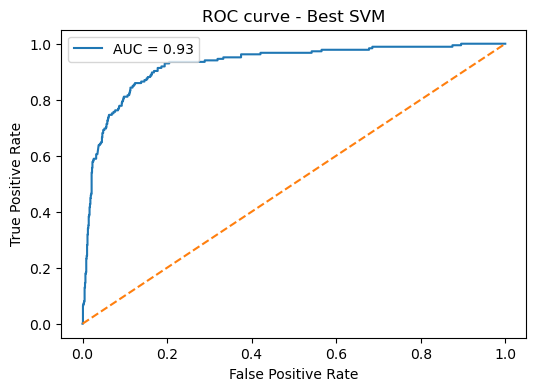

In [22]:
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1], linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve - Best SVM")
plt.legend()
plt.show()

The ROC curve for the tuned SVM model shows strong classification performance, with an Area Under the Curve(AUC) of 0.93. The curve lies close to the top left corner, indicating that the model achieves a high true positive rate while maintaining a low false positive rate across different thresholds. This suggests that the model is effective at distinguishing between drivers who finish in the top 3 and those who do not. The AUC value of 0.93 further confirms that the model has excellent discriminative ability, significantly better than a random classifier.

In [25]:
# Logistic regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred_log = log_model.predict(X_test_scaled)

In [27]:
accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy: {:.2f}%".format(accuracy*100))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 90.82%
Confusion Matrix:
 [[975  49]
 [ 62 123]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      1024
           1       0.72      0.66      0.69       185

    accuracy                           0.91      1209
   macro avg       0.83      0.81      0.82      1209
weighted avg       0.91      0.91      0.91      1209



The logistic regression model achieved an accuracy of 90.82%. From the confusion matrix, the model correctly classified 975 non-top 3 drivers and 123 top 3 drivers, while misclassifying 49 non-top 3 drivers as top 3 drivers and missing 62 actual top 3 drivers. The classification report shows strong performance for the non-top 3 class with high precision(0.94) and recall(0.95). For the top 3 class, the model achieved a precision of 0.72 and recall of 0.66, resulting in an F1-score of 0.69, indicating moderate performance in identifying top 3 finishes.

### Overall result
The SVM models and Logistic regression show very similar performance in this classification task. The tuned SVM(linear kernel, C=10), achieved an accuracy of 91.07%, slightly higher than logistic regression at 90.82%, indicating marginally better overall performance. Both models show identical precision(0.72) for the top 3 class, meaning they are equally reliable when predicting a top 3 finish. However, the tuned SVM model has a slightly higher recall(0.68) compared to logistic regression(0.66), suggesting it is marginally better at identifying actual top 3 drivers. The linear SVM and tuned SVM perform almost identically, while RBF SVM performs worse, particularly in recall(0.48), indicating it misses more top 3 drivers. Overall, the results suggest that the relationship in the data is mostly linear, as both linear SVM and logistic regression perform similarly while the non-linear SVM does not provide improvement.